In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv(r"c:\Users\nabee\Downloads\recipe_site_traffic.csv")
df

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN
...,...,...,...,...,...,...,...,...
942,943,1161.00,5.31,22.39,44.22,Lunch/Snacks,2,NaN
943,944,NaN,NaN,NaN,NaN,Potato,2,High
944,945,951.74,29.42,3.57,13.87,Pork,2,High
945,946,266.61,35.77,0.97,8.07,Potato,6,High


In [3]:
df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [5]:
df.tail()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
942,943,1161.00,5.31,22.39,44.22,Lunch/Snacks,2,NaN
943,944,NaN,NaN,NaN,NaN,Potato,2,High
944,945,951.74,29.42,3.57,13.87,Pork,2,High
945,946,266.61,35.77,0.97,8.07,Potato,6,High
946,947,184.56,45.21,6.20,0.03,Beverages,4,NaN


In [6]:
df.columns

Index(['recipe', 'calories', 'carbohydrate', 'sugar', 'protein', 'category',
       'servings', 'high_traffic'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [7]:
df.shape

(947, 8)

In [8]:
df.isnull().sum()

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64

In [ ]:
df.select_dtypes(include=['object']).columns


Index(['category', 'servings', 'high_traffic'], dtype='object')

In [17]:
heatmap=df.select_dtypes(include=['int','float'])

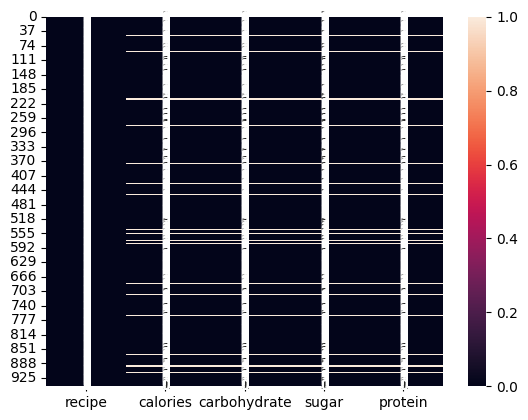

In [19]:
sns.heatmap(data=heatmap.isnull(),annot=True)
plt.show()

In [20]:
for i in [ 'calories', 'carbohydrate', 'sugar', 'protein']:
    df[i]=df[i].fillna(df[i].median())
    df[i]
    

In [21]:
df[ 'high_traffic']=df[ 'high_traffic'].fillna(df[ 'high_traffic'].mode()[0])


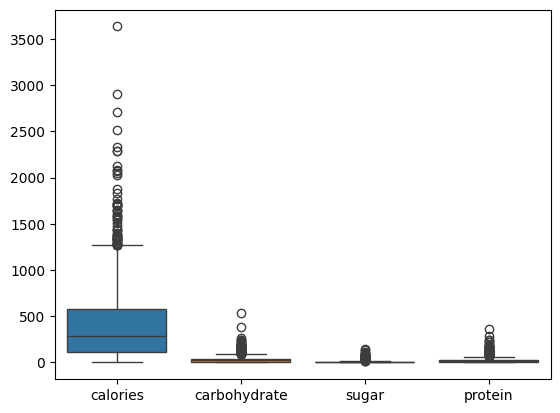

In [22]:
# oulier
num_cols=[ 'calories', 'carbohydrate', 'sugar', 'protein']
sns.boxplot(data=df[num_cols])
plt.show()

In [23]:
Q1=df['calories'].quantile(0.25)
Q2=df['calories'].quantile(0.50)
Q3=df['calories'].quantile(0.75)
print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['calories']:
    if((x>upper or (x<lower))):
        outlier.append(x)
print("outlier:",outlier)

114.41 288.55 576.225
461.81500000000005
1268.9475000000002
-578.3125000000001
outlier: [1695.82, 1321.78, 1724.25, 1279.53, 2122.24, 2508.47, 2081.69, 2906.01, 1568.0, 1330.3, 1292.18, 1330.48, 2703.12, 1550.2, 1767.53, 1435.35, 1878.82, 1277.97, 1706.75, 1337.71, 2282.6, 1362.81, 2051.34, 1830.28, 1646.83, 1503.92, 1542.53, 1272.1, 1295.21, 1375.2, 1715.48, 1440.69, 1635.46, 1275.23, 2029.33, 1580.48, 1610.06, 1291.46, 1271.9, 1428.47, 1348.4, 1694.81, 1335.54, 1588.26, 1402.99, 1377.61, 1317.56, 1270.46, 2068.07, 1370.8, 1356.45, 1646.67, 1471.33, 1716.03, 2332.32, 3633.16, 2283.29, 1337.5]


In [24]:
df1=df['calories']>upper
df.loc[df1].index

Index([ 17,  36,  49,  51,  55,  71,  97, 124, 147, 190, 217, 219, 226, 242,
       267, 285, 292, 299, 306, 355, 356, 381, 397, 418, 428, 437, 451, 470,
       487, 546, 547, 548, 566, 611, 636, 639, 642, 645, 667, 684, 694, 696,
       715, 721, 740, 752, 753, 775, 781, 805, 823, 861, 870, 887, 907, 925,
       939, 940],
      dtype='int64')

In [25]:
df.drop(df.loc[df1].index,inplace=True)

In [26]:

outlier=[]
for x in df['calories']:
    if((x>upper or (x<lower))):
        outlier.append(x)
print("outlier:",outlier)

outlier: []


In [27]:
Q1=df['carbohydrate'].quantile(0.25)
Q2=df['carbohydrate'].quantile(0.50)
Q3=df['carbohydrate'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['carbohydrate']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

9.18 21.48 42.68
33.5
92.93
-41.07


[99.82,
 95.89,
 98.51,
 145.32,
 190.84,
 156.23,
 101.73,
 239.06,
 113.65,
 154.18,
 158.92,
 243.2,
 111.8,
 191.21,
 142.22,
 128.22,
 140.96,
 96.03,
 177.22,
 142.28,
 102.52,
 383.06,
 202.66,
 118.2,
 119.63,
 530.42,
 173.93,
 163.33,
 103.46,
 100.7,
 195.8,
 181.98,
 140.98,
 210.77,
 126.97,
 113.99,
 94.81,
 127.47,
 102.72,
 138.05,
 107.12,
 170.88,
 140.22,
 162.11,
 124.16,
 96.71,
 265.09,
 127.12,
 133.9,
 224.16,
 111.08,
 162.91,
 102.44,
 135.88,
 228.67,
 114.65,
 157.92,
 194.26,
 151.69,
 97.21,
 159.72,
 126.18,
 96.11,
 131.8]

In [29]:
df2=df['carbohydrate']>upper
df.loc[df2].index

Index([ 37,  70,  78,  94, 127, 135, 159, 167, 177, 185, 227, 239, 243, 261,
       296, 307, 322, 324, 331, 339, 341, 349, 367, 413, 424, 450, 453, 469,
       481, 503, 521, 529, 540, 575, 576, 584, 617, 621, 677, 688, 691, 693,
       717, 719, 722, 726, 738, 746, 751, 761, 763, 787, 798, 815, 830, 842,
       843, 844, 846, 856, 885, 895, 904, 920],
      dtype='int64')

In [30]:
df.drop(df.loc[df2].index,inplace=True)

In [31]:
outlier=[]
for x in df['carbohydrate']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

[]

In [32]:
Q1=df['sugar'].quantile(0.25)
Q2=df['sugar'].quantile(0.50)
Q3=df['sugar'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)


upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['sugar']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier        

1.76 4.55 9.63
7.870000000000001
21.435000000000002
-10.045000000000002


[38.63,
 104.91,
 27.78,
 32.83,
 39.54,
 76.53,
 54.47,
 47.32,
 22.95,
 38.36,
 29.41,
 44.54,
 23.79,
 59.04,
 39.52,
 24.65,
 44.22,
 44.67,
 39.34,
 35.01,
 29.68,
 22.03,
 41.5,
 26.16,
 22.3,
 39.46,
 131.39,
 30.73,
 37.08,
 45.33,
 37.05,
 41.24,
 42.8,
 28.18,
 32.7,
 86.97,
 30.6,
 29.72,
 22.74,
 66.03,
 26.97,
 38.66,
 29.15,
 71.52,
 28.58,
 30.56,
 48.21,
 43.34,
 54.33,
 30.32,
 49.53,
 84.96,
 58.0,
 63.14,
 50.81,
 35.74,
 24.37,
 58.88,
 24.63,
 95.75,
 56.78,
 75.48,
 23.19,
 76.11,
 52.17,
 51.64,
 30.06,
 58.15,
 72.49,
 22.39]

In [33]:
df3=df['sugar']>upper
df.loc[df3].index

Index([  3,  21,  26,  31,  46,  59,  95,  96, 113, 118, 132, 133, 142, 155,
       169, 173, 175, 188, 191, 211, 218, 232, 234, 247, 266, 271, 290, 303,
       344, 346, 373, 378, 402, 416, 423, 426, 435, 440, 444, 467, 474, 482,
       493, 496, 513, 518, 533, 539, 544, 557, 590, 592, 654, 655, 660, 665,
       666, 668, 729, 737, 760, 810, 850, 860, 867, 916, 928, 931, 935, 942],
      dtype='int64')

In [34]:
df.drop(df.loc[df3].index,inplace=True)

In [35]:
df3=df['sugar']<lower
df.loc[df3].index

Index([], dtype='int64')

In [36]:
Q1=df['protein'].quantile(0.25)
Q2-df['protein'].quantile(0.50)
Q3=df['protein'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['protein']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

3.5 4.55 27.04
23.54
62.35
-31.810000000000002


[113.85,
 79.71,
 220.14,
 82.58,
 87.05,
 73.35,
 87.11,
 66.69,
 86.09,
 136.89,
 71.51,
 102.53,
 66.71,
 69.53,
 142.03,
 71.88,
 104.07,
 122.39,
 128.84,
 151.64,
 88.21,
 186.18,
 125.5,
 87.34,
 91.16,
 64.46,
 87.46,
 82.85,
 158.81,
 169.78,
 125.66,
 189.33,
 96.27,
 63.56,
 239.57,
 78.81,
 70.69,
 91.16,
 70.75,
 109.92,
 73.94,
 221.91,
 100.46,
 85.32,
 85.81,
 66.4,
 94.0,
 78.47,
 78.49,
 144.71,
 73.42,
 70.07,
 97.89,
 78.25,
 66.9,
 180.06,
 93.14,
 112.64,
 132.87,
 78.76,
 77.39,
 363.36,
 286.97,
 92.01,
 83.9,
 99.13,
 63.94,
 182.63,
 136.65,
 99.64,
 71.16,
 111.57,
 87.25]

In [37]:
df4=df['protein']>upper
df.loc[df4].index

Index([  9,  15,  29,  32,  43,  52,  54,  57,  61,  63,  68,  73, 106, 123,
       137, 162, 165, 176, 179, 196, 199, 206, 214, 228, 237, 255, 283, 309,
       313, 316, 319, 328, 333, 337, 342, 345, 353, 357, 358, 370, 377, 383,
       425, 446, 458, 480, 501, 510, 520, 522, 527, 563, 564, 583, 585, 616,
       637, 638, 641, 656, 678, 681, 695, 705, 748, 754, 776, 782, 801, 878,
       894, 903, 905],
      dtype='int64')

In [39]:
df.drop(df.loc[df4].index,inplace=True)

In [40]:
outlier=[]
for x in df['protein']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

[]

In [68]:
df.reset_index(drop=True,inplace=True)

In [69]:
# encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [70]:
df

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,288.55,21.48,4.55,10.80,8,6,0
1,2,35.48,38.56,0.66,0.92,9,4,0
2,3,914.28,42.68,3.09,2.88,1,1,0
3,5,27.05,1.85,0.80,0.53,0,4,0
4,6,691.15,3.46,1.65,53.93,7,2,0
...,...,...,...,...,...,...,...,...
677,942,186.21,83.94,1.98,22.40,3,4,0
678,944,288.55,21.48,4.55,10.80,9,2,0
679,945,951.74,29.42,3.57,13.87,8,2,0
680,946,266.61,35.77,0.97,8.07,9,6,0


In [71]:
df.category.nunique()

11

In [44]:
df.high_traffic.nunique()

1

In [ ]:
# df1=pd.get_dummies(df)
# df1

,recipe,calories,carbohydrate,sugar,protein,category_Beverages,category_Breakfast,category_Chicken,category_Chicken Breast,category_Dessert,...,category_One Dish Meal,category_Pork,category_Potato,category_Vegetable,servings_1,servings_2,servings_4,servings_4 as a snack,servings_6,high_traffic_High
0,1,288.55,21.48,4.55,10.80,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,True
1,2,35.48,38.56,0.66,0.92,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
2,3,914.28,42.68,3.09,2.88,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,5,27.05,1.85,0.80,0.53,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
5,6,691.15,3.46,1.65,53.93,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,942,186.21,83.94,1.98,22.40,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
943,944,288.55,21.48,4.55,10.80,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
944,945,951.74,29.42,3.57,13.87,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
945,946,266.61,35.77,0.97,8.07,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,True


In [ ]:
# df_1=pd.get_dummies(df1)
# df_1.astype('int')

,recipe,calories,carbohydrate,sugar,protein,category_Beverages,category_Breakfast,category_Chicken,category_Chicken Breast,category_Dessert,...,category_One Dish Meal,category_Pork,category_Potato,category_Vegetable,servings_1,servings_2,servings_4,servings_4 as a snack,servings_6,high_traffic_High
0,1,288,21,4,10,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
1,2,35,38,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,1
2,3,914,42,3,2,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,5,27,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
5,6,691,3,1,53,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,942,186,83,1,22,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
943,944,288,21,4,10,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
944,945,951,29,3,13,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
945,946,266,35,0,8,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1


In [72]:
le=LabelEncoder()

In [73]:
df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,288.55,21.48,4.55,10.80,8,6,0
1,2,35.48,38.56,0.66,0.92,9,4,0
2,3,914.28,42.68,3.09,2.88,1,1,0
3,5,27.05,1.85,0.80,0.53,0,4,0
4,6,691.15,3.46,1.65,53.93,7,2,0


In [84]:
cols=['category', 'high_traffic','servings']
for i in cols:
   df[i]=le.fit_transform(df[i])


In [85]:
df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,288.55,21.48,4.55,10.80,8,4,0
1,2,35.48,38.56,0.66,0.92,9,2,0
2,3,914.28,42.68,3.09,2.88,1,0,0
3,5,27.05,1.85,0.80,0.53,0,2,0
4,6,691.15,3.46,1.65,53.93,7,1,0


In [86]:
# scaling

scaler=MinMaxScaler(feature_range=(0,1))

In [87]:
x=df.drop(['high_traffic','category','servings'],axis=1)


In [89]:
y=df[['high_traffic','category','servings']]
y

,high_traffic,category,servings
0,0,8,4
1,0,9,2
2,0,1,0
3,0,0,2
4,0,7,1
...,...,...,...
677,0,3,2
678,0,9,1
679,0,8,1
680,0,9,4


In [90]:
x

,recipe,calories,carbohydrate,sugar,protein
0,1,288.55,21.48,4.55,10.80
1,2,35.48,38.56,0.66,0.92
2,3,914.28,42.68,3.09,2.88
3,5,27.05,1.85,0.80,0.53
4,6,691.15,3.46,1.65,53.93
...,...,...,...,...,...
677,942,186.21,83.94,1.98,22.40
678,944,288.55,21.48,4.55,10.80
679,945,951.74,29.42,3.57,13.87
680,946,266.61,35.77,0.97,8.07


In [91]:
x1=scaler.fit_transform(x)
x1

array([[0.00000000e+00, 2.30393567e-01, 2.32117736e-01, 2.16396568e-01,
        1.73969072e-01],
       [1.05708245e-03, 2.81188056e-02, 4.16946218e-01, 3.09818875e-02,
        1.48195876e-02],
       [2.11416490e-03, 7.30529446e-01, 4.61530137e-01, 1.46806482e-01,
        4.63917526e-02],
       ...,
       [9.97885835e-01, 7.60470618e-01, 3.18039173e-01, 1.69685415e-01,
        2.23421392e-01],
       [9.98942918e-01, 2.12857280e-01, 3.86754680e-01, 4.57578646e-02,
        1.29993557e-01],
       [1.00000000e+00, 1.47276041e-01, 4.88908127e-01, 2.95042898e-01,
        4.83247423e-04]], shape=(682, 5))

In [93]:
x2=pd.DataFrame(x1,columns=['recipe','calories','	carbohydrate','sugar','protein'])
x2

,recipe,calories,\tcarbohydrate,sugar,protein
0,0.000000,0.230394,0.232118,0.216397,0.173969
1,0.001057,0.028119,0.416946,0.030982,0.014820
2,0.002114,0.730529,0.461530,0.146806,0.046392
3,0.004228,0.021381,0.019695,0.037655,0.008537
4,0.005285,0.552185,0.037117,0.078170,0.868718
...,...,...,...,...,...
677,0.994715,0.148595,0.908019,0.093899,0.360825
678,0.996829,0.230394,0.232118,0.216397,0.173969
679,0.997886,0.760471,0.318039,0.169685,0.223421
680,0.998943,0.212857,0.386755,0.045758,0.129994


In [94]:
x3=pd.concat([x2,y],axis=1)
x3

,recipe,calories,\tcarbohydrate,sugar,protein,high_traffic,category,servings
0,0.000000,0.230394,0.232118,0.216397,0.173969,0,8,4
1,0.001057,0.028119,0.416946,0.030982,0.014820,0,9,2
2,0.002114,0.730529,0.461530,0.146806,0.046392,0,1,0
3,0.004228,0.021381,0.019695,0.037655,0.008537,0,0,2
4,0.005285,0.552185,0.037117,0.078170,0.868718,0,7,1
...,...,...,...,...,...,...,...,...
677,0.994715,0.148595,0.908019,0.093899,0.360825,0,3,2
678,0.996829,0.230394,0.232118,0.216397,0.173969,0,9,1
679,0.997886,0.760471,0.318039,0.169685,0.223421,0,8,1
680,0.998943,0.212857,0.386755,0.045758,0.129994,0,9,4


c:\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\nabee\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


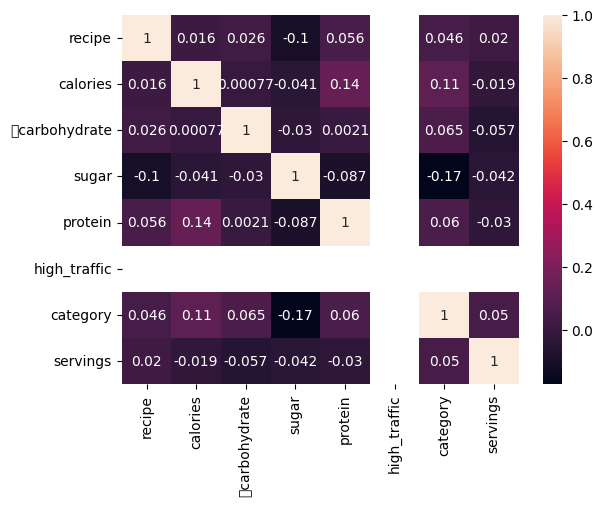

In [95]:
sns.heatmap(x3.corr(),annot=True)
plt.show()

C:\Users\nabee\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


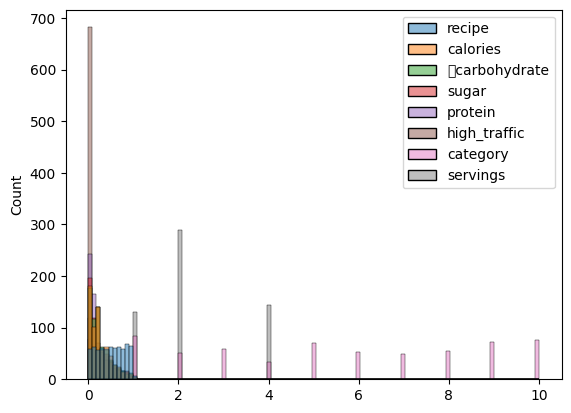

In [96]:
sns.histplot(data=x3)
plt.show()

C:\Users\nabee\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


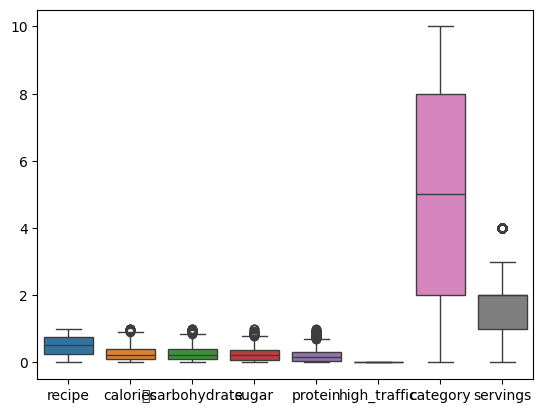

In [97]:
sns.boxplot(data=x3)
plt.show()

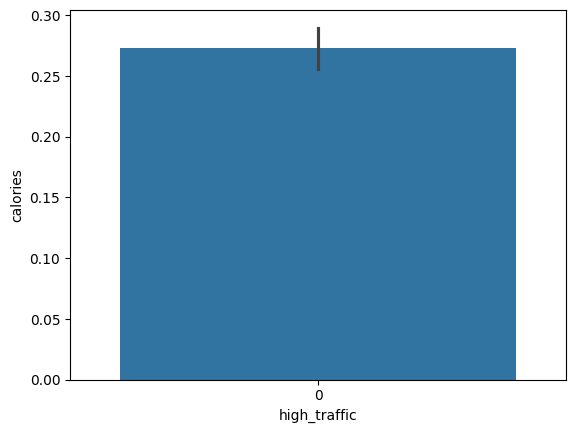

In [98]:
sns.barplot(data=x3,x='high_traffic',y='calories')
plt.show()

c:\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\nabee\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


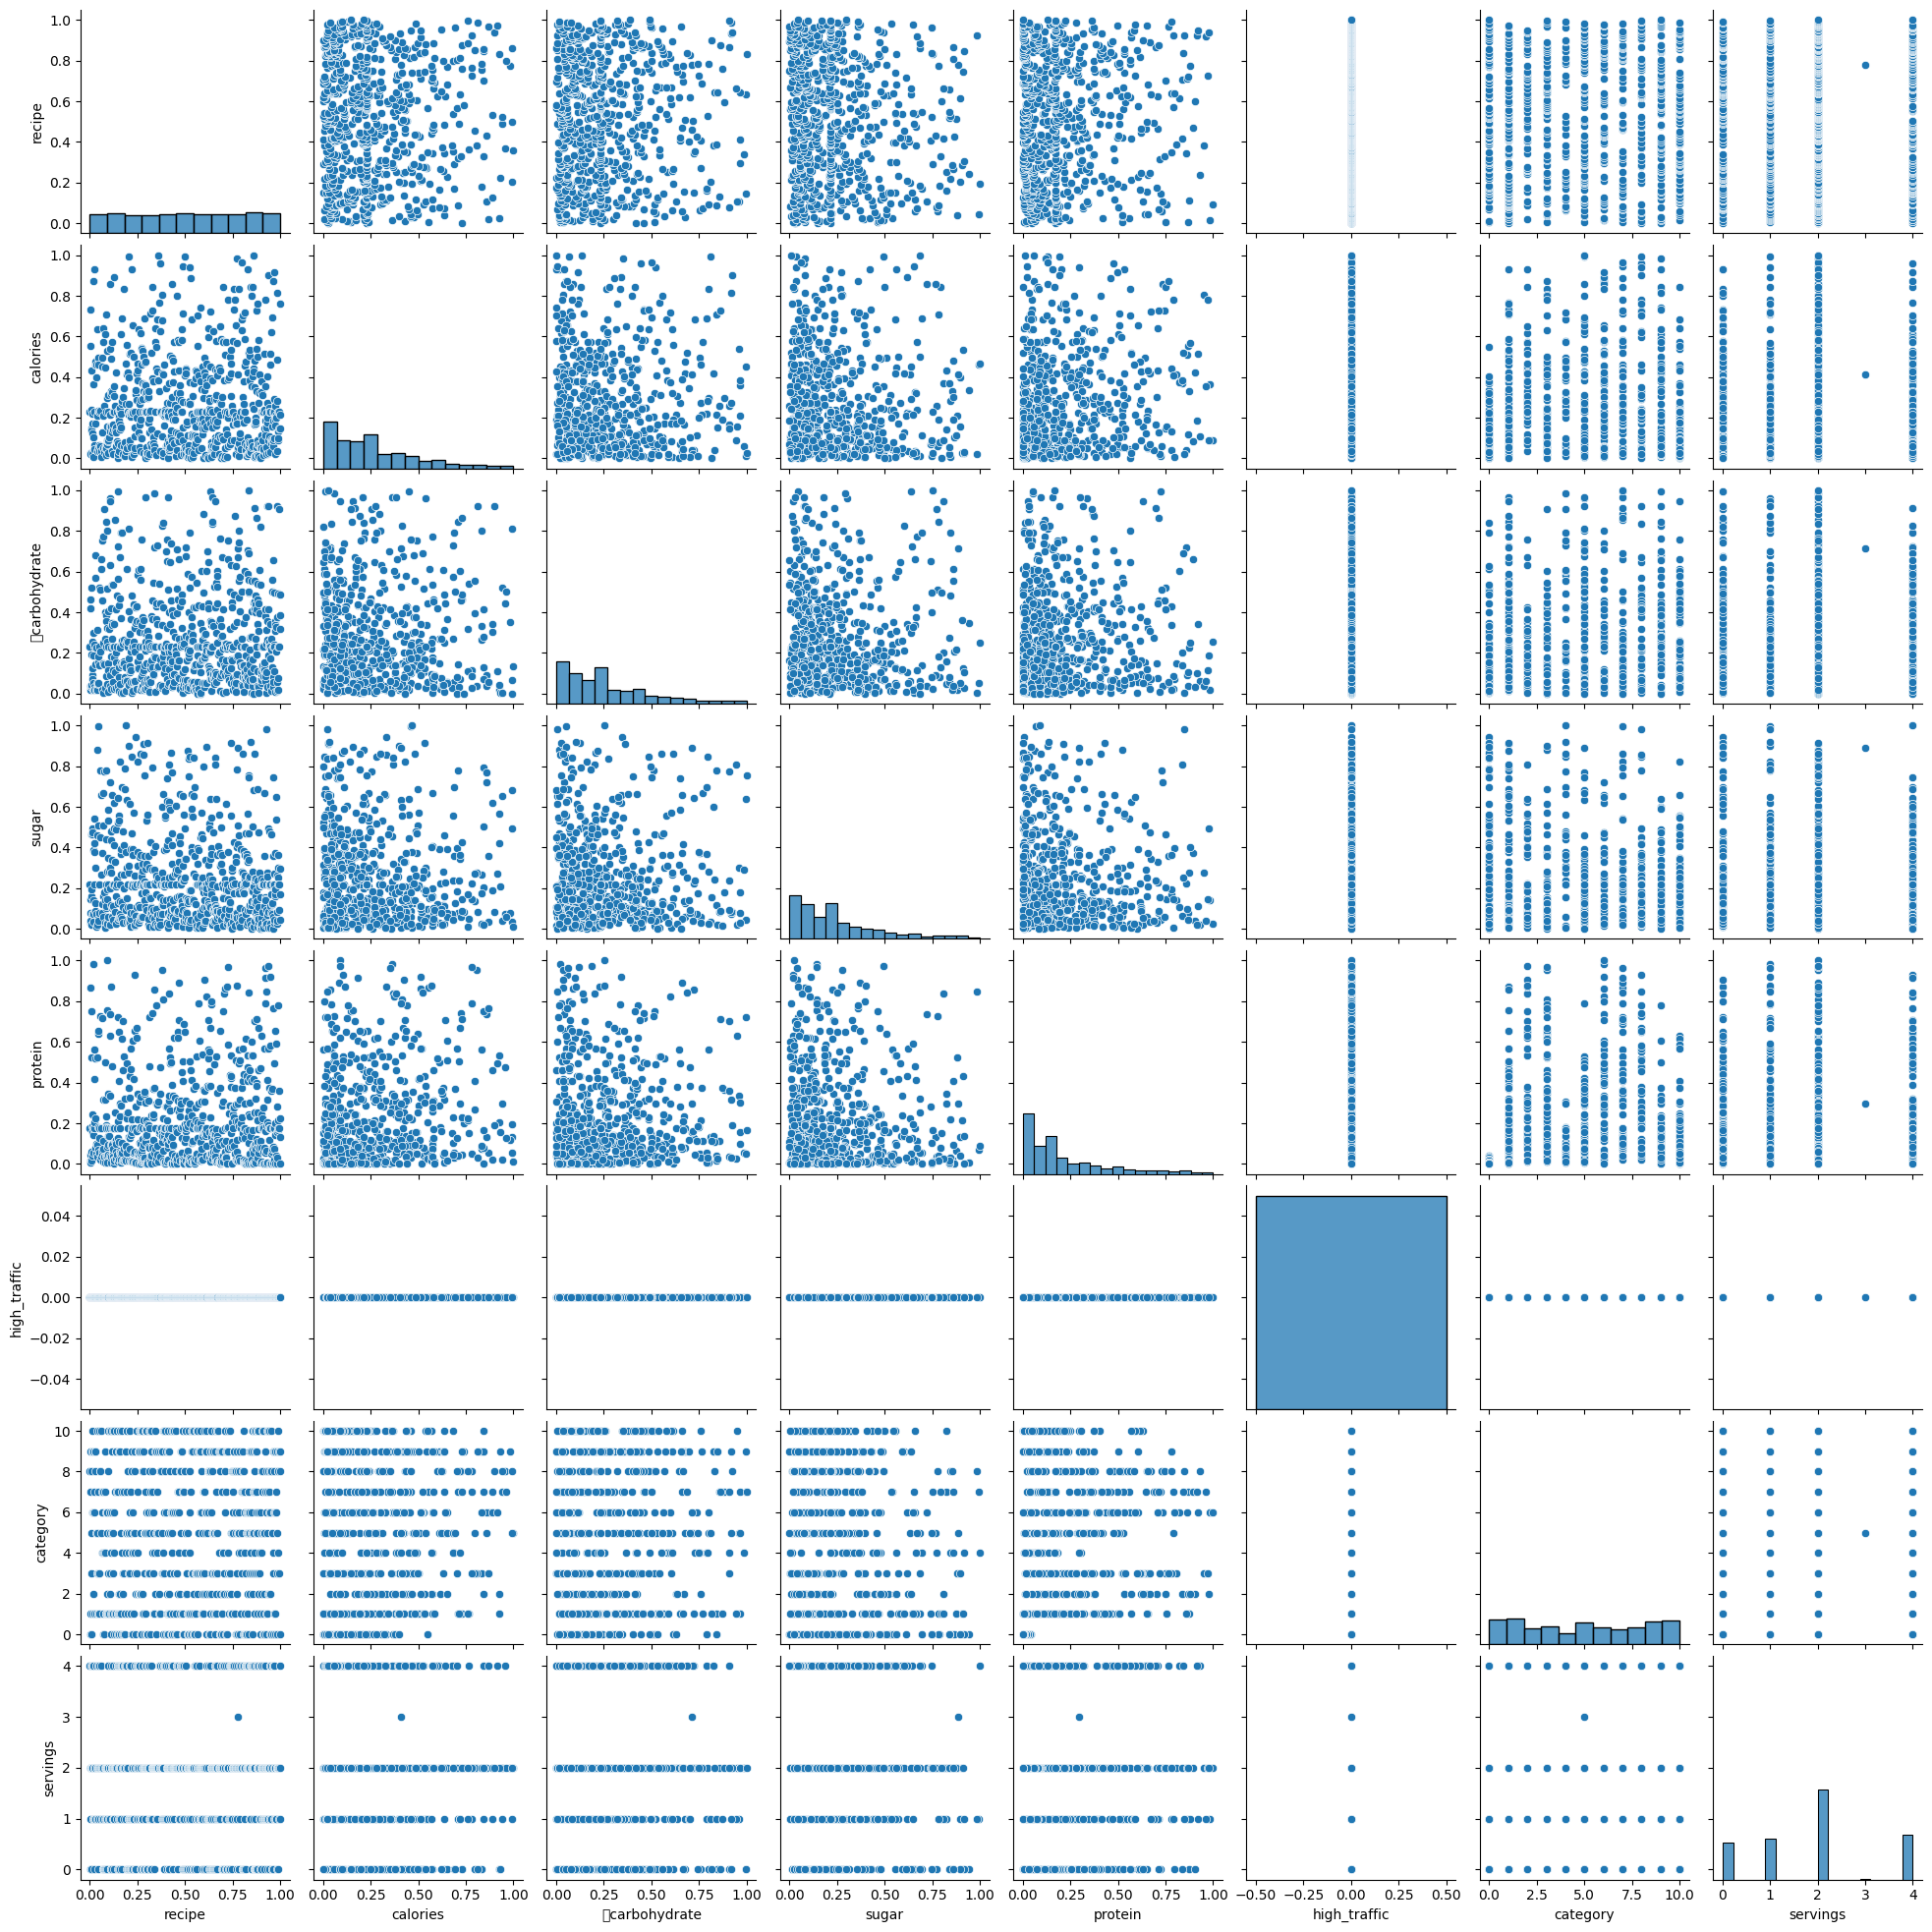

In [99]:
sns.pairplot(x3)
plt.show()